# Notebook 1: Data Loading & EDA — Liver Cancer Gene Expression

**Dataset:** GSE14520_U133A — GPL571 Affymetrix microarray  
**Task:** Binary classification — Hepatocellular Carcinoma (HCC) vs Normal liver tissue  
**Input file:** `Liver_GSE14520_U133A.csv`  
**Output file:** `liver_clean.csv`

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

> **Change `data_dir` to match your Google Drive path before running.**

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project')

raw_file   = data_dir / 'Liver_GSE14520_U133A.csv'
clean_file = data_dir / 'liver_clean.csv'

target_col    = 'type'
sample_col    = 'samples'
class_pos     = 'HCC'
class_neg     = 'normal'
top_n_genes   = 20
heatmap_genes = 30

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load the Raw Dataset

In [5]:
df = pd.read_csv(raw_file, low_memory=False)

print(f'Shape      : {df.shape[0]} samples x {df.shape[1]} columns')
print(f'Classes    : {df[target_col].unique().tolist()}')
print(f'Gene probes: {df.shape[1] - 2:,}')
df.head(3)

Shape      : 357 samples x 22279 columns
Classes    : ['HCC', 'normal']
Gene probes: 22,277


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,GSM362958.CEL.gz,HCC,6.801198,4.553189,6.787790,5.430893,3.250222,6.272688,3.413405,3.374910,...,10.735084,10.398843,12.298551,12.270505,3.855588,3.148321,3.366087,3.199008,3.160388,3.366417
1,GSM362959.CEL.gz,HCC,7.585956,4.193540,3.763183,6.003593,3.309387,6.291927,3.754777,3.587603,...,11.528447,11.369919,12.867048,12.560433,4.016561,3.282867,3.541994,3.548680,3.460083,3.423348
2,GSM362960.CEL.gz,HCC,7.803370,4.134075,3.433113,5.395057,3.476944,5.825713,3.505036,3.687333,...,10.892460,10.416151,12.356337,11.888482,3.839367,3.598851,3.516791,3.484089,3.282626,3.512024


## 4. Initial Inspection

In [6]:
gene_cols = [c for c in df.columns if c not in (sample_col, target_col)]

print(df[[target_col]].dtypes)
print(f'All {len(gene_cols):,} gene columns numeric: {all(pd.api.types.is_numeric_dtype(df[c]) for c in gene_cols)}')

missing_total = df.isnull().sum().sum()
print(f'Missing values: {missing_total}')

display(df[gene_cols[:5]].describe().round(3))

type    object
dtype: object
All 22,277 gene columns numeric: True
Missing values: 0


,1007_s_at,1053_at,117_at,121_at,1255_g_at
count,357.000,357.000,357.000,357.000,357.000
mean,6.920,4.365,3.998,5.676,3.197
std,0.795,0.517,0.458,0.324,0.118
min,5.440,3.208,3.350,4.843,2.927
25%,6.459,4.023,3.757,5.471,3.114
50%,6.775,4.246,3.899,5.664,3.184
75%,7.142,4.603,4.126,5.885,3.270
max,10.204,7.118,8.452,6.421,3.624


## 5. EDA — Class Distribution

  HCC           181 samples  (50.7%)
  normal        176 samples  (49.3%)
  Total         357 samples


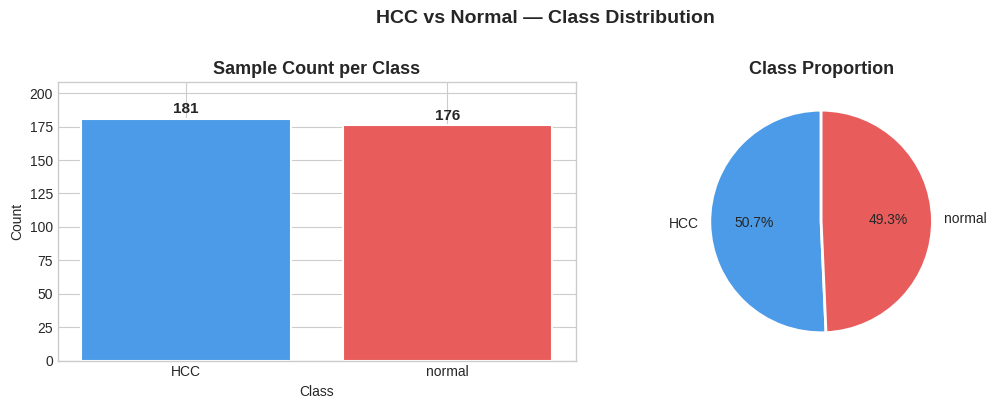

In [7]:
counts = df[target_col].value_counts()
pcts   = df[target_col].value_counts(normalize=True) * 100

for cls in counts.index:
    print(f'  {cls:<10}  {counts[cls]:>5} samples  ({pcts[cls]:.1f}%)')
print(f'  Total       {counts.sum():>5} samples')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#4C9BE8', '#E85C5C']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 2, str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Sample Count per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('HCC vs Normal — Class Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**

The dataset contains a total of 357 samples. The data is very evenly split between the two categories:
- **HCC (Liver Cancer):** 181 samples (about 50.7%)
- **Normal:** 176 samples (about 49.3%)

Because the two groups are almost perfectly equal in size, the dataset is considered "balanced." This is great news for machine learning, as we won't need to use special techniques to handle an underrepresented class.

## 6. EDA — Missing Value Analysis

In [8]:
missing_per_col   = df[gene_cols].isnull().mean() * 100
cols_with_missing = missing_per_col[missing_per_col > 0]

print(f'Columns with missing values: {len(cols_with_missing):,} / {len(gene_cols):,}')

if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    cols_with_missing.sort_values(ascending=False).head(50).plot(
        kind='bar', ax=ax, color='#4C9BE8', edgecolor='white'
    )
    ax.axhline(50, color='orange', linestyle='--', linewidth=1.5, label='50% threshold')
    ax.axhline(90, color='red',    linestyle='--', linewidth=1.5, label='90% threshold')
    ax.set_title('Top-50 Probes by Missing Value %', fontsize=13, fontweight='bold')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Probe')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values — chart skipped.')

Columns with missing values: 0 / 22,277
No missing values — chart skipped.


## 7. EDA — Top Variable Genes: Expression Distributions by Class

We select the top genes by variance to focus EDA on the most informative probes.

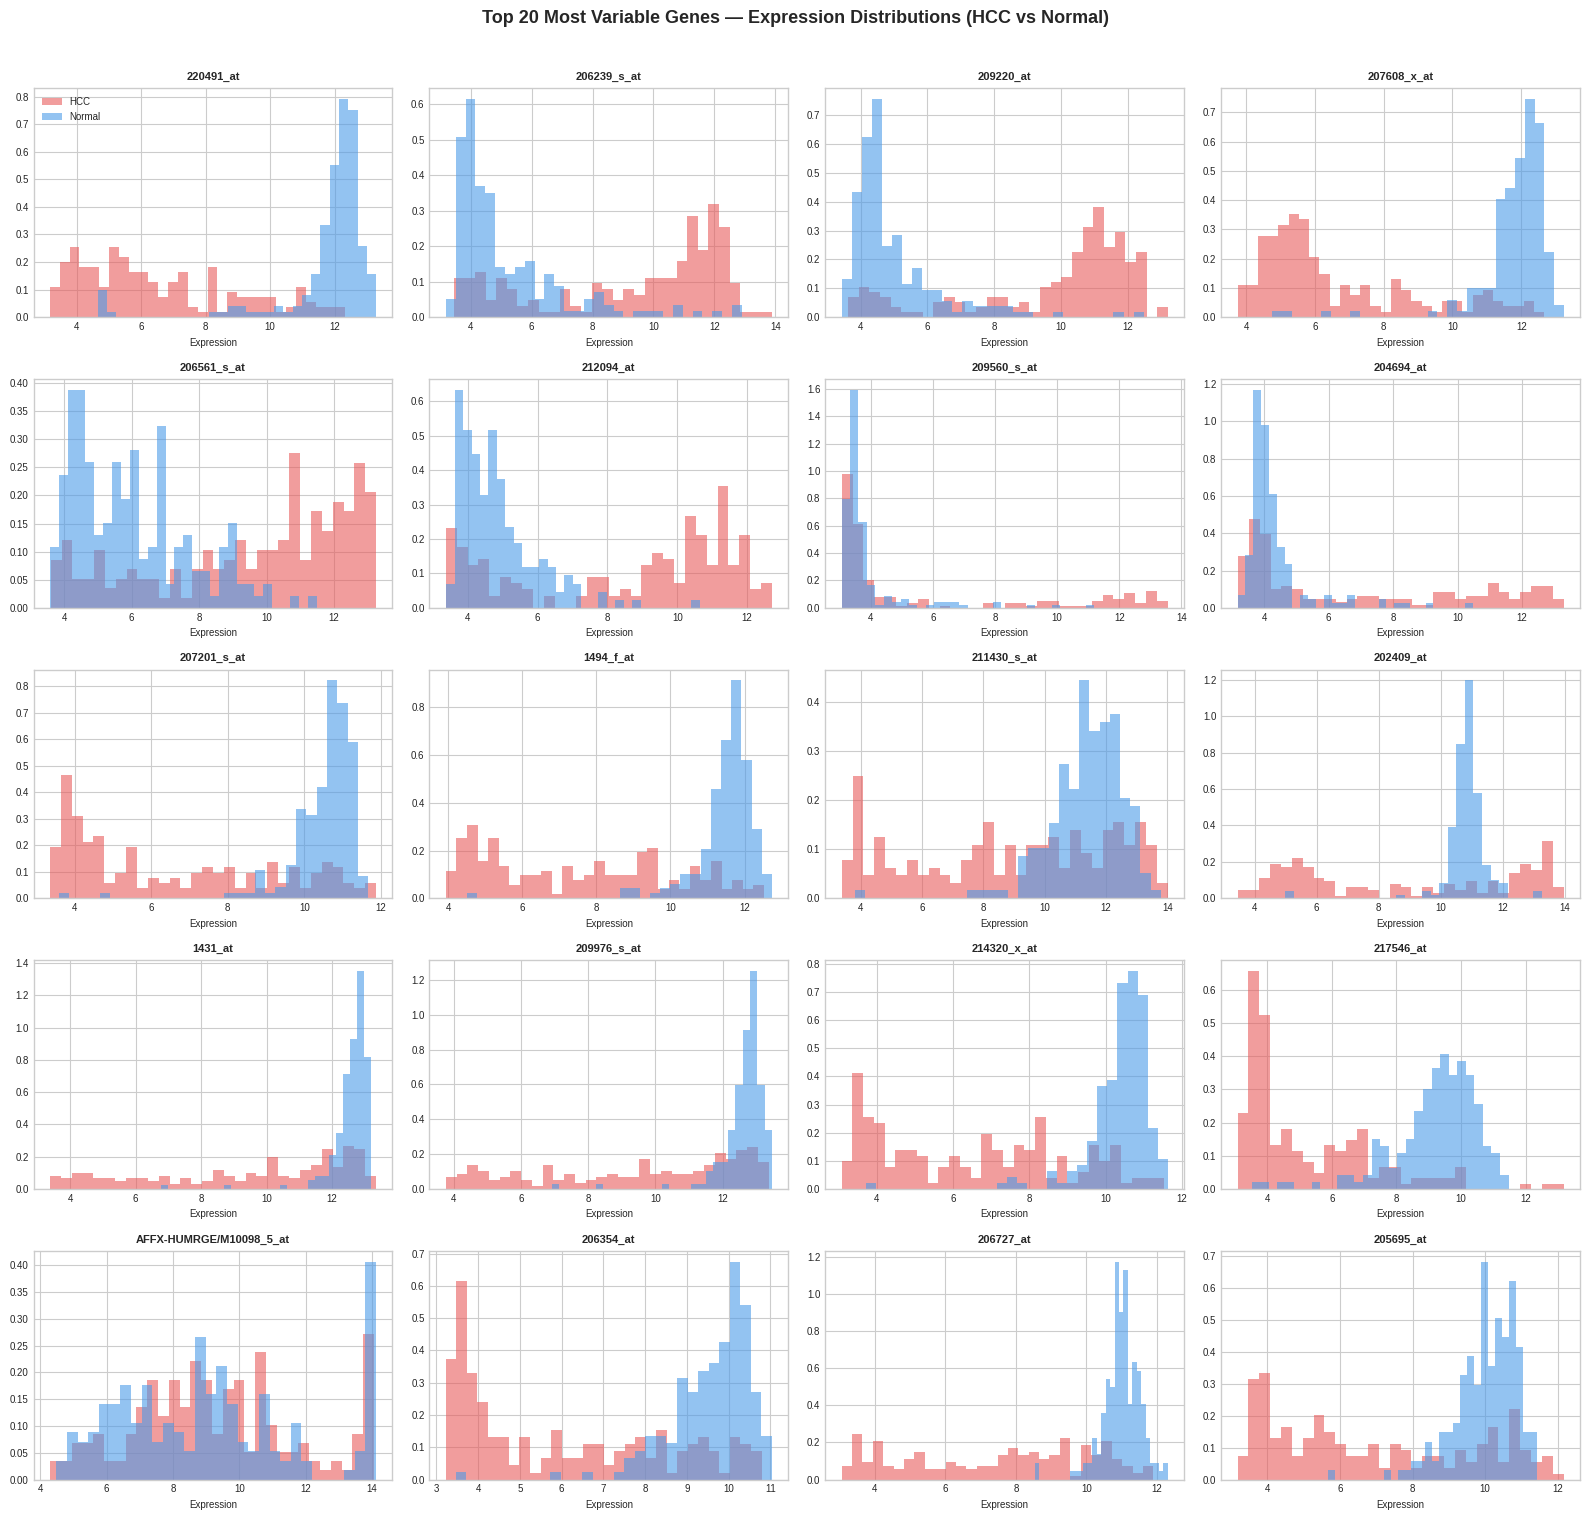

In [9]:
gene_var  = df[gene_cols].var().sort_values(ascending=False)
top_genes = gene_var.head(top_n_genes).index.tolist()

hcc_df    = df[df[target_col] == class_pos]
normal_df = df[df[target_col] == class_neg]

n_cols = 4
n_rows = (top_n_genes + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, gene in enumerate(top_genes):
    ax = axes[i]
    ax.hist(hcc_df[gene],    bins=30, alpha=0.6, color='#E85C5C', label='HCC',    density=True)
    ax.hist(normal_df[gene], bins=30, alpha=0.6, color='#4C9BE8', label='Normal', density=True)
    ax.set_title(gene, fontsize=8, fontweight='bold')
    ax.set_xlabel('Expression', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top {top_n_genes} Most Variable Genes — Expression Distributions (HCC vs Normal)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**

These charts show the expression levels of the top 20 most "variable" genes—the genes whose activity changes the most across all our samples.

- **Red areas** represent HCC (Liver Cancer) samples.
- **Blue areas** represent Normal tissue samples.

**Why does this matter?**
When the red and blue shapes are far apart or peak in different places, it means that specific gene behaves very differently in a healthy liver compared to a cancerous one. Genes with less overlap between the red and blue areas are strong indicators of cancer, making them excellent clues for our machine learning model to learn from.

## 8. EDA — Box Plots: Top Variable Genes by Class

/tmp/ipykernel_595/3520189000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_595/3520189000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_595/3520189000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_595/3520189000.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_595/3520189000.py:13: FutureWarning: 

Passin

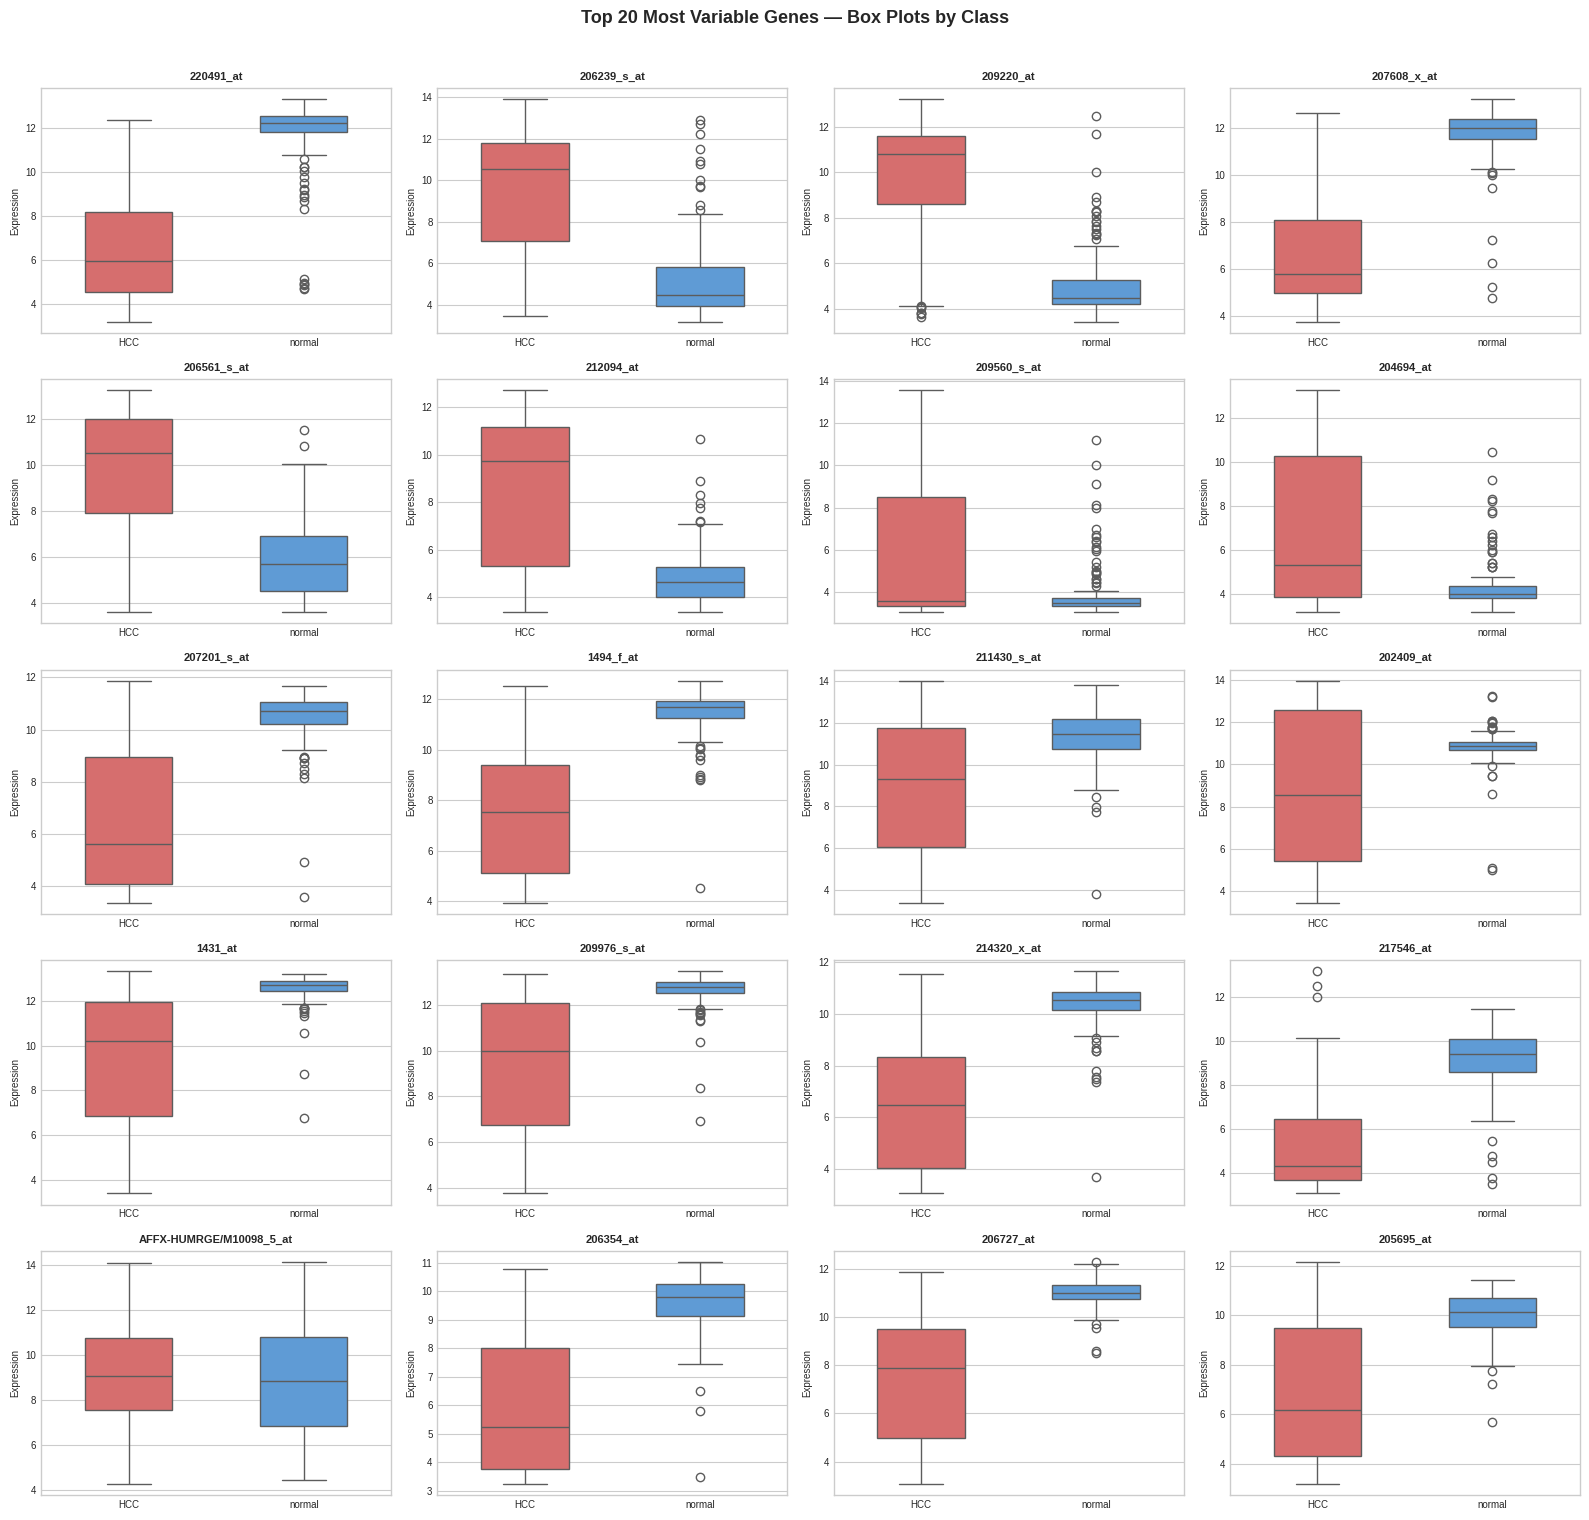

In [10]:
plot_df = df[[target_col] + top_genes].melt(id_vars=target_col, var_name='Gene', value_name='Expression')

n_cols = 4
n_rows = (top_n_genes + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

palette = {class_pos: '#E85C5C', class_neg: '#4C9BE8'}

for i, gene in enumerate(top_genes):
    ax = axes[i]
    subset = plot_df[plot_df['Gene'] == gene]
    sns.boxplot(
        data=subset, x=target_col, y='Expression',
        palette=palette, width=0.5, ax=ax,
        order=[class_pos, class_neg]
    )
    ax.set_title(gene, fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Expression', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Top {top_n_genes} Most Variable Genes — Box Plots by Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**

These box plots provide another way to look at the top 20 most "variable" genes.

- The **box** shows where the middle 50% of the data lies for each group (Red for HCC, Blue for Normal).
- The **line inside the box** is the median (the exact middle value).
- The **whiskers** extending from the boxes show the full range of typical values, while the individual dots are "outliers" (unusual values).

**Why does this matter?**
Just like the histograms above, we are looking for differences between the red and blue boxes. If a red box is much higher or lower than its corresponding blue box with very little overlap, it strongly suggests that this gene's activity is a good marker for telling cancer and normal tissue apart.

## 9. EDA — Correlation Heatmap (Top Variable Genes)

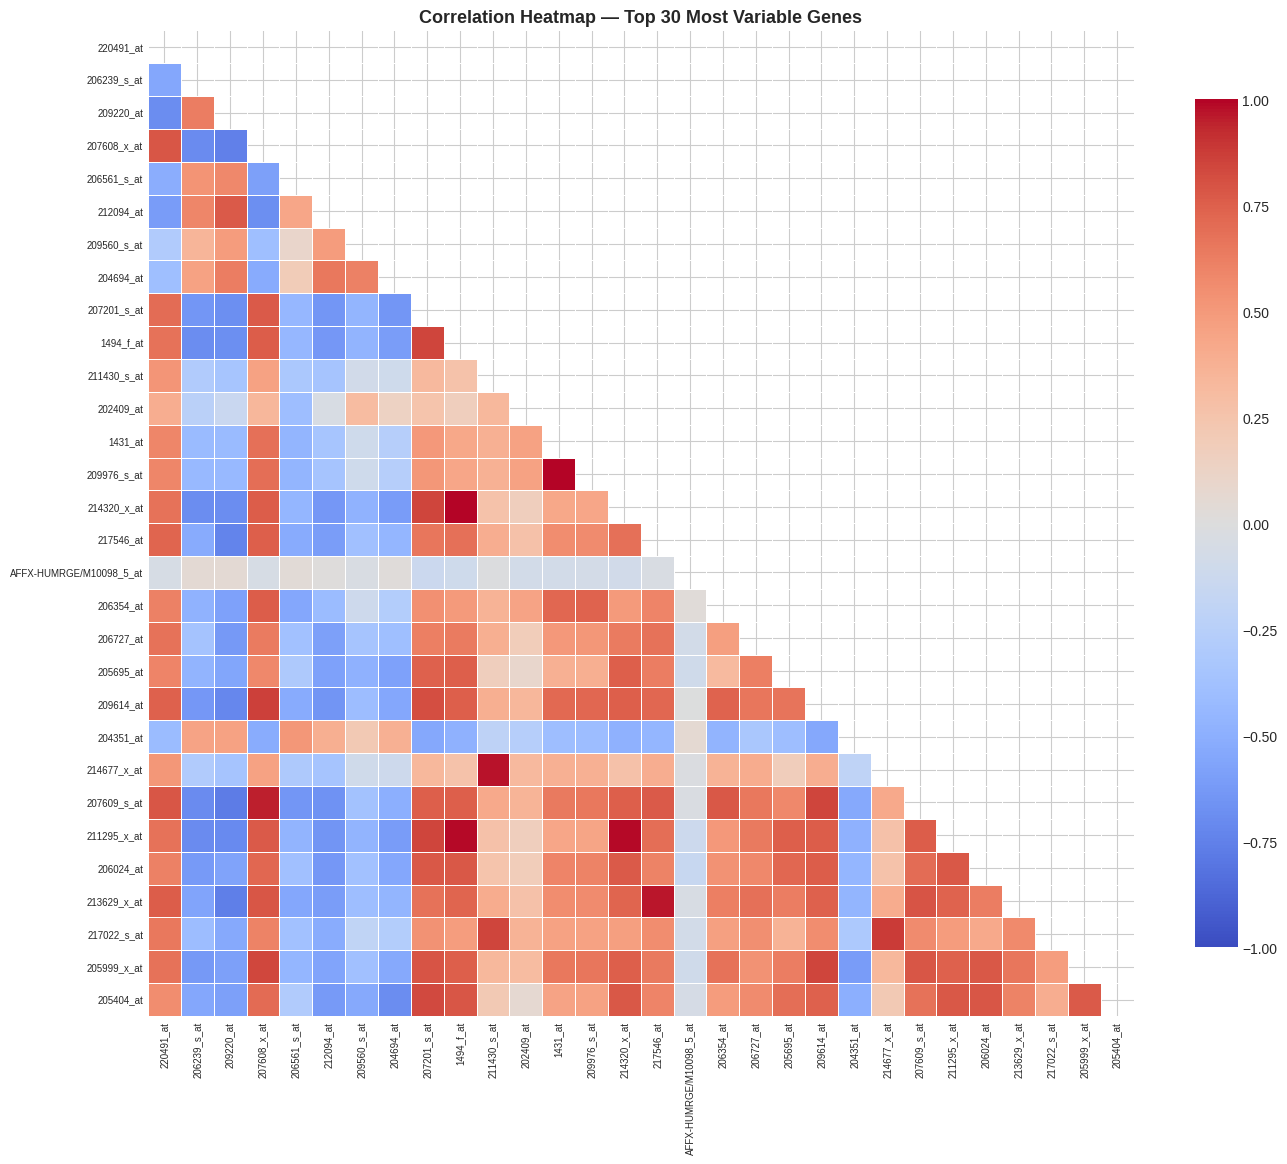

,Gene_A,Gene_B,r
0,209976_s_at,1431_at,0.996508
1,214320_x_at,1494_f_at,0.996468
2,211295_x_at,1494_f_at,0.992178
3,211295_x_at,214320_x_at,0.990293
4,214677_x_at,211430_s_at,0.976508
5,213629_x_at,217546_at,0.966040
6,207609_s_at,207608_x_at,0.947006
7,217022_s_at,214677_x_at,0.881399
8,209614_at,207608_x_at,0.864633
9,211295_x_at,207201_s_at,0.850180


In [11]:
heatmap_gene_list = gene_var.head(heatmap_genes).index.tolist()
corr = df[heatmap_gene_list].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.4,
    annot=False, cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title(f'Correlation Heatmap — Top {heatmap_genes} Most Variable Genes',
             fontsize=13, fontweight='bold')
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(~mask)
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Gene_A', 'level_1': 'Gene_B', 0: 'r'})
    .assign(abs_r=lambda x: x['r'].abs())
    .sort_values('abs_r', ascending=False)
    .head(10)
)
display(corr_pairs[['Gene_A', 'Gene_B', 'r']].reset_index(drop=True))

**Interpretation:**

This **correlation heatmap** shows how different genes relate to each other.
- **Red squares** mean two genes are "positively correlated"—when one gene's activity goes up, the other usually goes up too.
- **Blue squares** mean they are "negatively correlated"—when one goes up, the other tends to go down.
- The darker the color, the stronger the relationship.

**Why is the heatmap shaped like a triangle?**
If we drew a full square, the top-right half would be an exact mirror image of the bottom-left half (since comparing Gene A to Gene B gives the exact same result as comparing Gene B to Gene A). Additionally, the diagonal line would just be comparing each gene to itself (which is always a perfect match). By cutting it in half and only showing the triangle, we remove all the duplicate information, making the chart cleaner and much easier to read!

## 10. EDA — Overall Gene Expression Distribution

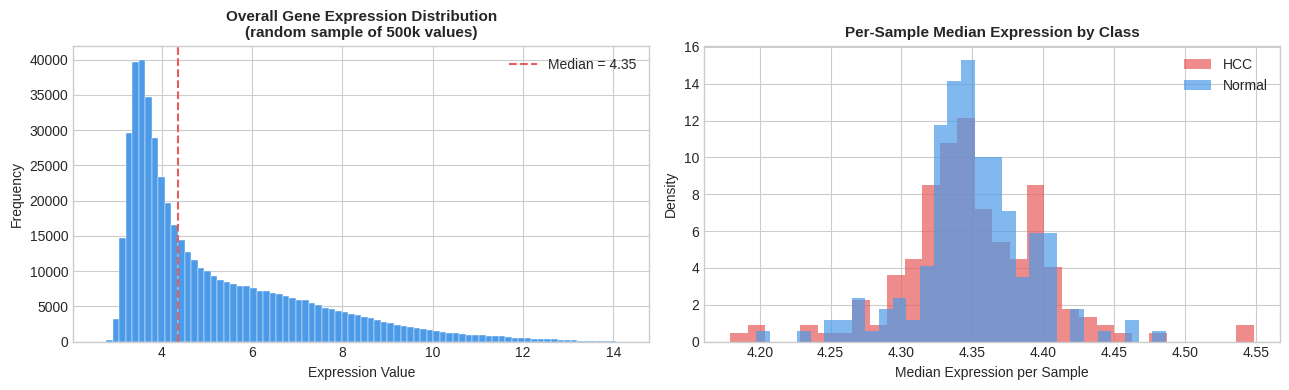

In [12]:
sample_vals = df[gene_cols].values.flatten()
rng     = np.random.default_rng(42)
sampled = rng.choice(sample_vals, size=min(500_000, len(sample_vals)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sampled, bins=80, color='#4C9BE8', edgecolor='white', linewidth=0.3)
axes[0].set_title('Overall Gene Expression Distribution\n(random sample of 500k values)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Expression Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(sampled), color='#E85C5C', linestyle='--',
                linewidth=1.5, label=f'Median = {np.median(sampled):.2f}')
axes[0].legend()

hcc_medians    = hcc_df[gene_cols].median(axis=1)
normal_medians = normal_df[gene_cols].median(axis=1)
axes[1].hist(hcc_medians,    bins=30, alpha=0.7, color='#E85C5C', label='HCC',    density=True)
axes[1].hist(normal_medians, bins=30, alpha=0.7, color='#4C9BE8', label='Normal', density=True)
axes[1].set_title('Per-Sample Median Expression by Class', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Median Expression per Sample')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**

These two charts give us a "big picture" view of all the data combined.

- **Left Chart (Overall Distribution):** This looks at a huge random sample of all gene activity levels across all patients. It shows us what a "typical" gene activity level looks like in this dataset. Most values are clustered around the middle (the dotted median line).
  *Think of gene expression like dimmer switches rather than simple on/off switches. The bottom axis (Expression Value) is how "bright" the switch is turned up, and the side axis (Frequency) is how many times we saw that brightness level. The large hump in the middle tells us most genes operate at a medium, baseline level.*

- **Right Chart (Average per Patient):** This chart calculates the "average" (median) gene activity for each individual patient, and then separates them by Cancer (Red) and Normal (Blue).

**Why does this matter?**
Notice how the red and blue curves on the right chart are almost identical and sitting right on top of each other. This tells us that the *overall* amount of gene activity is basically the same in healthy livers and cancerous livers. The cancer isn't caused by the whole liver working "harder" or "slower" overall—instead, the cancer is driven by *specific* genes turning on or off (which is why those earlier charts looking at individual genes are so important!).

## 11. Save Cleaned Dataset

In [13]:
df_clean = df.drop(columns=[sample_col])

df_clean.to_csv(clean_file, index=False)
print(f'Saved: {clean_file}')
print(f'Shape: {df_clean.shape[0]} samples x {df_clean.shape[1]} columns')

Saved: /content/drive/MyDrive/Colab Notebooks/Cumida Liver ML Project/liver_clean.csv
Shape: 357 samples x 22278 columns


## 12. Summary

In [14]:
print(f'Dataset     : GSE14520_U133A (GPL571)')
print(f'Samples     : {df.shape[0]}  ({class_pos}: {counts[class_pos]}, {class_neg}: {counts[class_neg]})')
print(f'Gene probes : {len(gene_cols):,}')
print(f'Missing     : {missing_total}')
print(f'Output      : liver_clean.csv')

Dataset     : GSE14520_U133A (GPL571)
Samples     : 357  (HCC: 181, normal: 176)
Gene probes : 22,277
Missing     : 0
Output      : liver_clean.csv
